# ASWIFT-style SI_1

Updated 1 × 3 ASWIFT-style layout with magma weight maps, boxed axes, inset color scales, derpsalsa weights filled at missing values, scientific-notation derpsalsa weight ticks, and panel aspect matched to FIG_5.


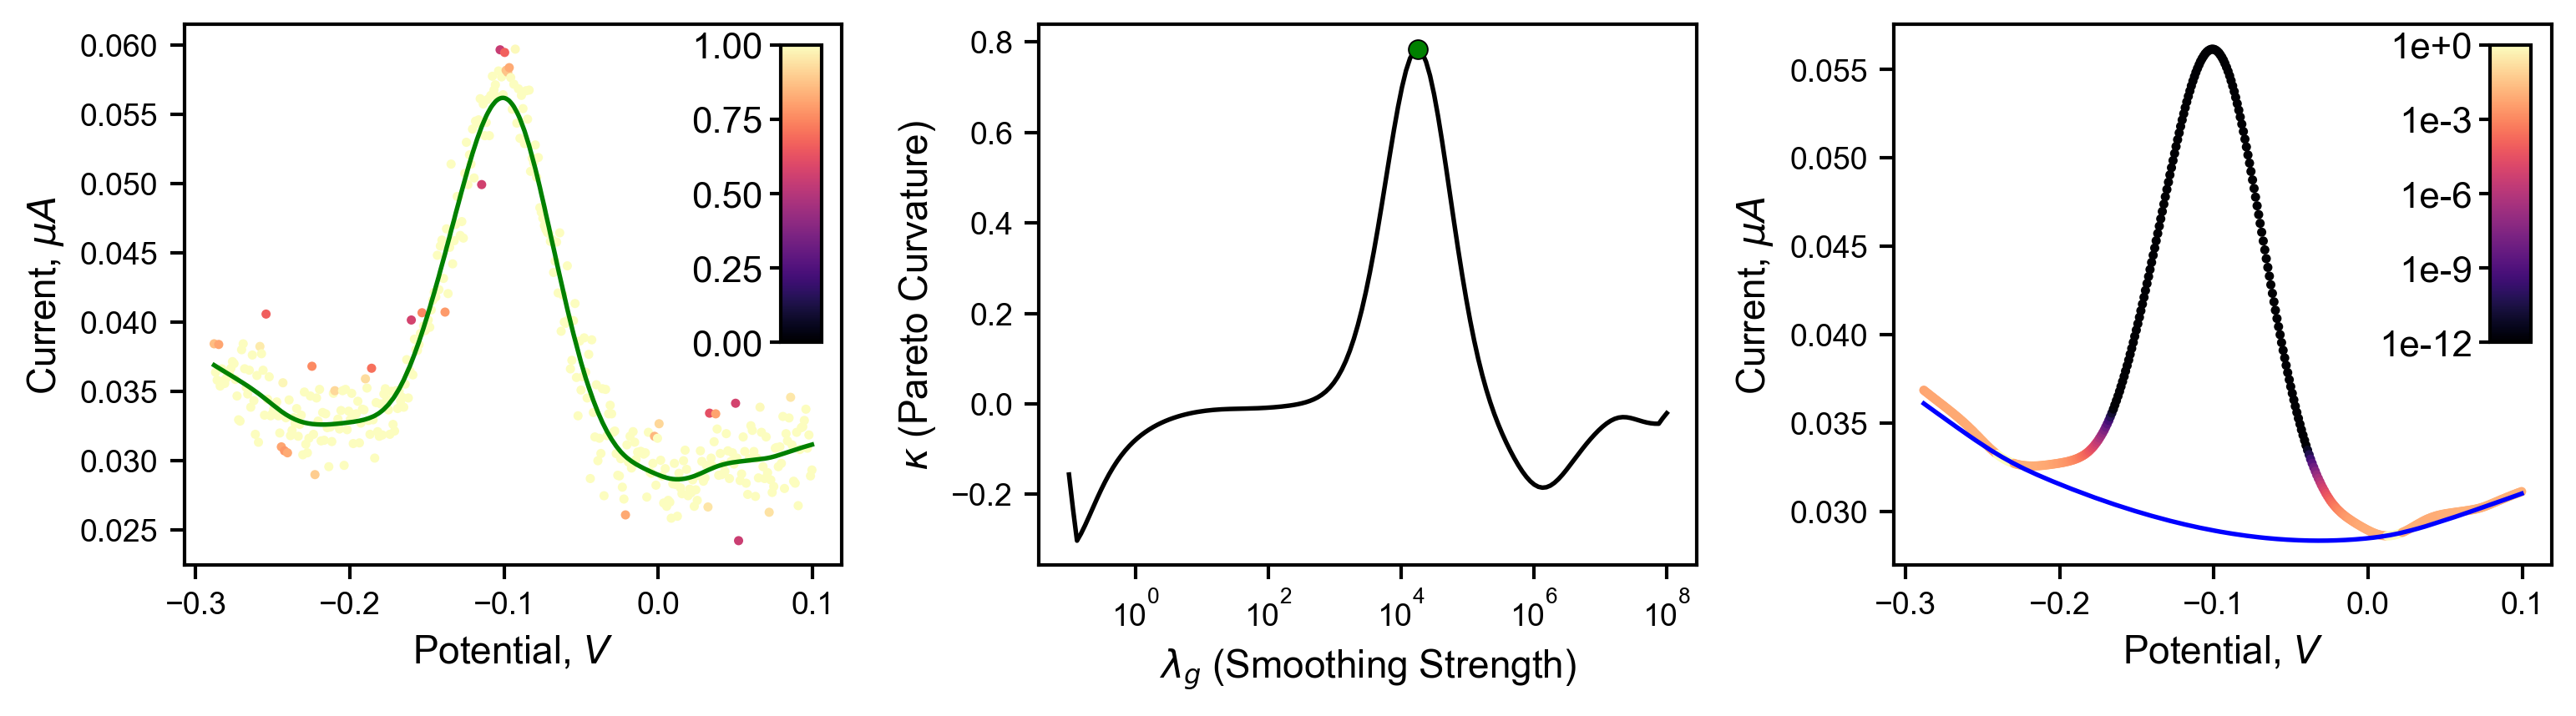

NameError: name 'fig6' is not defined

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator, FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pybaselines import Baseline

from peak_extraction.extract_peaks import (
    choose_lambda_lcurve,
    choose_lambda_area,
    huber_reweighted_lcurve,
)


# ---------- ASWIFT-style settings, matched to the FIG_2 / FIG_5 notebooks ----------
def set_figure_style():
    plt.rcParams.update({
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 4.0,
        "ytick.major.size": 4.0,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "mathtext.default": "it",
    })


def save_figure(fig, stem, out_dir="figure_exports", transparent=False):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for ext in ["png", "pdf", "svg"]:
        fig.savefig(out_dir / f"{stem}.{ext}", bbox_inches="tight", transparent=transparent)


def read_csv(path, channel=0):
    df = (
        pd.read_csv(path, skiprows=6, encoding="utf-16")
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
    )
    volts = df.iloc[:, 0].astype(float).to_numpy()
    currents = df.iloc[:, 1::2].dropna(how="all").astype(float).to_numpy().T
    return volts, currents[channel]


def _call_choose_lambda_lcurve(y, n_grid=150):
    """Compatibility wrapper in case your local function lacks n_grid."""
    try:
        return choose_lambda_lcurve(y, n_grid=n_grid)
    except TypeError:
        return choose_lambda_lcurve(y)


def _call_huber_reweighted_lcurve(y, g0, n_grid=150):
    """Compatibility wrapper in case your local function lacks n_grid."""
    try:
        return huber_reweighted_lcurve(y, g0, n_grid=n_grid)
    except TypeError:
        return huber_reweighted_lcurve(y, g0)


def _call_choose_lambda_area(g, volts, search_space=150):
    """Compatibility wrapper in case your local function lacks search_space."""
    try:
        return choose_lambda_area(g, volts, search_space=search_space)
    except TypeError:
        return choose_lambda_area(g, volts)


def _safe_lognorm(values, eps=1e-12):
    values = np.asarray(values, dtype=float)
    # Fill missing, non-finite, and non-positive derpsalsa weights with 1.0 so
    # every point is rendered and neutral/default weights remain visible.
    values = np.where(np.isfinite(values) & (values > 0), values, 1.0)
    values_pos = np.clip(values, eps, None)
    finite = values_pos[np.isfinite(values_pos)]
    if finite.size == 0:
        raise ValueError("No finite derpsalsa weights were found.")

    vmin = float(np.nanmin(finite))
    vmax = float(np.nanmax(finite))
    if np.isclose(vmin, vmax):
        vmin = max(eps, vmin / 10)
        vmax = max(vmin * 10, vmax * 10)

    return values_pos, mcolors.LogNorm(vmin=vmin, vmax=vmax)



def _add_inset_colorbar(
    fig,
    ax,
    mappable,
    title,
    scientific=False,
    *,
    width="6.2%",          # larger colorbar thickness
    height="55%",          # larger colorbar length
    loc="upper right",
    borderpad=0.65,        # smaller = closer to the corner / more over the data
    tick_fontsize=10.5,    # tick-label font size
    title_fontsize=11.0,   # colorbar title font size
    tick_width=1.0,
    tick_length=3.2,
    tick_pad=2.0,
    title_pad=4.8,
    title_x=-0.15,
    title_ha="left",
    facecolor="white",
    face_alpha=0.88,
    zorder=1000,
):
    """
    In-axis colorbar drawn above the data. The white backing prevents plotted
    points/lines from visually competing with the colorbar and tick labels.
    """
    cax = inset_axes(
        ax,
        width=width,
        height=height,
        loc=loc,
        borderpad=borderpad,
    )
    cax.set_zorder(zorder)
    cax.set_facecolor(facecolor)
    cax.patch.set_alpha(face_alpha)

    cbar = fig.colorbar(mappable, cax=cax)
    cbar.ax.set_zorder(zorder + 1)
    cbar.ax.set_facecolor(facecolor)
    cbar.ax.patch.set_alpha(face_alpha)
    cbar.ax.yaxis.set_ticks_position("left")
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.tick_params(labelsize=tick_fontsize, width=tick_width, length=tick_length, pad=tick_pad)
    cbar.ax.set_title(title, fontsize=title_fontsize, pad=title_pad, x=title_x, ha=title_ha)

    if scientific:
        cbar.locator = LogLocator(base=10)
        cbar.formatter = FuncFormatter(
            lambda x, pos: "" if (x <= 0 or not np.isfinite(x)) else f"{x:.0e}".replace("e-0", "e-").replace("e+0", "e+")
        )
        cbar.update_ticks()

    for txt in list(cbar.ax.get_yticklabels()) + [cbar.ax.title]:
        txt.set_bbox(dict(facecolor=facecolor, alpha=face_alpha, edgecolor="none", pad=0.25))

    if hasattr(cbar, "solids") and cbar.solids is not None:
        cbar.solids.set_alpha(1.0)
    cbar.outline.set_linewidth(tick_width)
    return cbar


def _format_clean_axes(axes):
    for ax in np.ravel(axes):
        for spine in ["top", "right", "bottom", "left"]:
            ax.spines[spine].set_visible(True)


def calculate_si_1_inputs(
    csv_path,
    channel=0,
    drop_first=10,
    n_grid=150,
    baseline_search_space=150,
):
    """
    Runs the smoothing L-curve, Huber-like reweighting, and derpsalsa baseline
    optimization used for SI_1.
    """
    volts, current = read_csv(csv_path, channel=channel)

    if drop_first:
        volts = volts[drop_first:]
        current = current[drop_first:]

    # Initial L-curve smoothing and Pareto curvature.
    lam_lcurve, g0, lcurve_results = _call_choose_lambda_lcurve(current, n_grid=n_grid)

    # Huber-like reweighted smoothing using the initial smoother as the seed.
    lam_huber, g, huber_results = _call_huber_reweighted_lcurve(current, g0, n_grid=n_grid)
    huber_weights = np.asarray(huber_results["weights"], dtype=float)

    # Use curvature arrays from the Huber results if available; otherwise use the
    # initial L-curve results. This keeps the plot robust to either implementation.
    if isinstance(huber_results, dict) and {"lams", "kappa"}.issubset(huber_results):
        curvature_results = huber_results
        lam_curvature = lam_huber
    else:
        curvature_results = lcurve_results
        lam_curvature = lam_lcurve

    lams = np.asarray(curvature_results["lams"], dtype=float)
    kappa = np.asarray(curvature_results["kappa"], dtype=float)

    # Derpsalsa lambda selection and final optimal weights on the smoothed trace.
    lam_ds, background, area_results = _call_choose_lambda_area(
        g, volts, search_space=baseline_search_space
    )

    derpsalsa_weights = None
    if isinstance(area_results, dict):
        for key in ["weights", "v", "derpsalsa_weights"]:
            if key in area_results:
                derpsalsa_weights = np.asarray(area_results[key], dtype=float)
                break

    # Recompute at the selected lambda if choose_lambda_area does not expose weights.
    if derpsalsa_weights is None:
        bl_fitter = Baseline(x_data=volts)
        background, ds_params = bl_fitter.derpsalsa(g, lam=lam_ds)
        derpsalsa_weights = np.asarray(ds_params["weights"], dtype=float)

    # Fill missing, non-finite, and non-positive derpsalsa weights with 1.0 so
    # empty/default points do not disappear from the scatter plot.
    derpsalsa_weights = np.asarray(derpsalsa_weights, dtype=float)
    derpsalsa_weights = np.where(np.isfinite(derpsalsa_weights) & (derpsalsa_weights > 0), derpsalsa_weights, 1.0)

    return {
        "volts": volts,
        "current": current,
        "g0": g0,
        "g": g,
        "lam_lcurve": lam_lcurve,
        "lam_huber": lam_huber,
        "huber_weights": huber_weights,
        "lams": lams,
        "kappa": kappa,
        "lam_curvature": lam_curvature,
        "lam_ds": lam_ds,
        "background": np.asarray(background, dtype=float),
        "derpsalsa_weights": derpsalsa_weights,
    }


def plot_si_1(
    csv_path,
    channel=0,
    drop_first=10,
    n_grid=150,
    baseline_search_space=150,
    figsize=(10.5, 3.13),
    show_panel_labels=False,
    show_titles=False,
):
    set_figure_style()
    data = calculate_si_1_inputs(
        csv_path=csv_path,
        channel=channel,
        drop_first=drop_first,
        n_grid=n_grid,
        baseline_search_space=baseline_search_space,
    )

    volts = data["volts"]
    current = data["current"]
    g = data["g"]
    background = data["background"]

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharex=False)
    # Match FIG_5 panel geometry: same left/right margins and column spacing,
    # with a taller one-row figure so each axis has the same width:height ratio.
    fig.subplots_adjust(top=0.92, bottom=0.23, left=0.080, right=0.980, wspace=0.30)

    # ---------- Panel 1: final Huber-like smoothing weights ----------
    ax = axes[0]
    huber_weights = np.asarray(data["huber_weights"], dtype=float)
    sc_huber = ax.scatter(
        volts,
        current,
        c=huber_weights,
        s=7,
        cmap="magma",
        norm=mcolors.Normalize(vmin=0, vmax=1),
        linewidths=0,
        zorder=2,
    )
    ax.plot(volts, g, color="green", lw=1.30, zorder=3)
    ax.set_xlabel(r"Potential, $V$")
    ax.set_ylabel(r"Current, $\mu A$")
    if show_titles:
        ax.set_title("Huber reweighting")
    _add_inset_colorbar(fig, ax, sc_huber, "")

    # ---------- Panel 2: curvature used to choose lambda ----------
    ax = axes[1]
    lams = np.asarray(data["lams"], dtype=float)
    kappa = np.asarray(data["kappa"], dtype=float)
    finite = np.isfinite(lams) & np.isfinite(kappa) & (lams > 0)
    lams_plot = lams[finite]
    kappa_plot = kappa[finite]

    ax.plot(lams_plot, kappa_plot, color="black", lw=1.30)
    if lams_plot.size:
        idx = np.nanargmin(np.abs(lams_plot - data["lam_curvature"]))
        ax.scatter(
            lams_plot[idx],
            kappa_plot[idx],
            s=30,
            color="green",
            edgecolor="black",
            linewidth=0.45,
            zorder=4,
        )
    ax.set_xscale("log")
    ax.set_xlabel(r"$\lambda_g$ (Smoothing Strength)")
    ax.set_ylabel(r"$\kappa$ (Pareto Curvature)")
    if show_titles:
        ax.set_title(r"Curvature, $\kappa$")

    # ---------- Panel 3: optimal derpsalsa weights on a log scale ----------
    ax = axes[2]
    ds_weights_pos, ds_norm = _safe_lognorm(data["derpsalsa_weights"])
    ds_norm = mcolors.LogNorm(
    vmin=ds_norm.vmin,
    vmax=1.0,
    )

    sc_ds = ax.scatter(
        volts,
        g,
        c=ds_weights_pos,
        s=7,
        cmap="magma",
        norm=ds_norm,
        linewidths=0,
        zorder=2,
    )
    ax.plot(volts, background, color="blue", lw=1.30, zorder=3)
    ax.set_xlabel(r"Potential, $V$")
    ax.set_ylabel(r"Current, $\mu A$")
    if show_titles:
        ax.set_title("Derpsalsa weights")
    _add_inset_colorbar(fig, ax, sc_ds, "", scientific=True)

    if show_panel_labels:
        for label, ax in zip(["a", "b", "c"], axes):
            ax.text(
                -0.18,
                1.10,
                label,
                transform=ax.transAxes,
                fontsize=14,
                fontweight="bold",
                va="top",
                ha="left",
            )

    _format_clean_axes(axes)
    return fig, data


# ---------- Run SI_1 ----------
csv_path = Path('/Users/Max_1/Soh Lab/echem/05_ATP Calib Curve Day 5/150hz-15.csv')

fig_si_1, si_1_data = plot_si_1(
    csv_path=csv_path,
    channel=0,
    drop_first=10,
    n_grid=150,
    baseline_search_space=150,
    figsize=(10.5, 3.13),
    show_panel_labels=False,
    show_titles=False,
)

plt.show()

# Change out_dir if you want this saved elsewhere.
save_figure(
    fig6,
    "SI_1",
    out_dir="figure_exports",
    transparent=True,
)
